# Projekt Analiza Obrazu

## Konrad Angelo

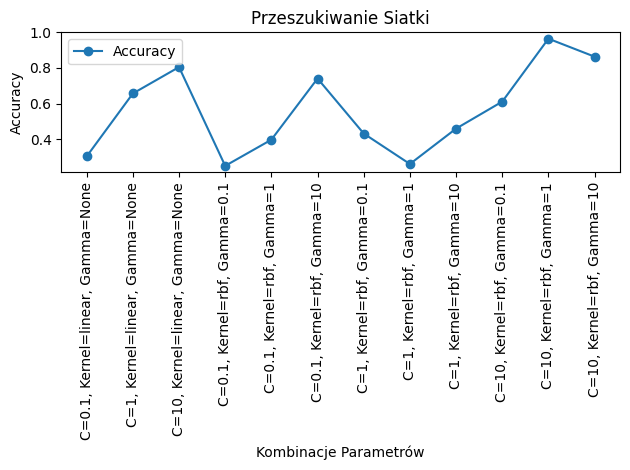

In [1]:
import matplotlib.pyplot as plt
import numpy as np

# Parametry
C_values = [0.1, 1, 10]
gamma_values = [0.1, 1, 10]

# Kombinacje
combinations = [
    (C, 'linear', None) for C in C_values
] + [
    (C, 'rbf', gamma) for C in C_values for gamma in gamma_values
]

# Tworzenie wykresu
fig, ax = plt.subplots()
x = np.arange(len(combinations))
y = [np.random.random() for _ in combinations]  # Przypadkowe wyniki accuracy

# Opisy osi
labels = [f'C={C}, Kernel={kernel}, Gamma={gamma}' for C, kernel, gamma in combinations]

# Rysowanie wykresu
ax.plot(x, y, 'o-', label='Accuracy')
ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=90)
ax.set_xlabel('Kombinacje Parametrów')
ax.set_ylabel('Accuracy')
ax.set_title('Przeszukiwanie Siatki')
ax.legend()

plt.tight_layout()
plt.show()

# Biblioteki 

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import cv2
import os
import numpy as np
import tensorflow as tf

import warnings
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import VGG16, InceptionResNetV2, MobileNetV2
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.applications import DenseNet121
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten, Dropout, GlobalAveragePooling2D
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.layers import GlobalAveragePooling2D, Dropout, Dense
from tensorflow.keras.models import Model


train = "/kaggle/input/sports-classification/train"
test =  "/kaggle/input/sports-classification/test"
valid= "/kaggle/input/sports-classification/valid"
warnings.filterwarnings('ignore')

# Opis Zbioru 
Zbiór danych pobrałem z Kaggle https://www.kaggle.com/datasets/gpiosenka/sports-classification. 

Zbiór danych sportowych zawierający obrazy 100 różnych dyscyplin sportowych.Dane są uporządkowane w katalogach: treningowym, testowym i walidacyjnym. 

Zestaw treningowy zawiera 13493 obrazów 

Zestaw walidacyjny zawiera 500 obrazów 

Zestawe testowy zawiera 500 obrazów 

Wszystkie obrazy są 224 X 224 X 3 w formacie jpg.

# Wyświetlenie klas 

In [7]:
classes = [d for d in os.listdir(train) if os.path.isdir(os.path.join(train, d))]

print(classes)

['bobsled', 'hurdles', 'snow boarding', 'fly fishing', 'luge', 'sidecar racing', 'ampute football', 'volleyball', 'billiards', 'giant slalom', 'tennis', 'horse racing', 'pole dancing', 'figure skating women', 'rollerblade racing', 'fencing', 'olympic wrestling', 'golf', 'ultimate', 'harness racing', 'football', 'frisbee', 'bungee jumping', 'shot put', 'ice climbing', 'figure skating men', 'rowing', 'bike polo', 'swimming', 'judo', 'axe throwing', 'archery', 'baseball', 'wheelchair basketball', 'log rolling', 'lacrosse', 'rock climbing', 'horse jumping', 'hydroplane racing', 'formula 1 racing', 'curling', 'jousting', 'javelin', 'water cycling', 'speed skating', 'barell racing', 'bull riding', 'horseshoe pitching', 'croquet', 'chuckwagon racing', 'hammer throw', 'rugby', 'pole climbing', 'nascar racing', 'snowmobile racing', 'boxing', 'mushing', 'track bicycle', 'canoe slamon', 'disc golf', 'bmx', 'air hockey', 'rings', 'trapeze', 'motorcycle racing', 'tug of war', 'ski jumping', 'field 

# Przygotowanie generatorów danych do treningu, walidacji i testowania modeli

In [5]:
train_data_generator = ImageDataGenerator(
        shear_range=0.2,
        zoom_range=0.2,
        width_shift_range=0.2,height_shift_range=0.2,
        horizontal_flip=True)

validation_data_generator = ImageDataGenerator()
test_data_generator = ImageDataGenerator()

train_generator = train_data_generator.flow_from_directory(
    train,
    target_size = (224, 224),
    batch_size=128,
    class_mode='categorical', shuffle=True, seed=42
)

validation_generator = validation_data_generator.flow_from_directory(
    valid,
    target_size = (224, 224),
    batch_size=128,
    shuffle = False,
    class_mode='categorical', seed=42
)

test_generator = test_data_generator.flow_from_directory(
    test,
    target_size = (224, 224),
    batch_size=128,
    shuffle = False,
    class_mode='categorical', seed=42
)

Found 13492 images belonging to 100 classes.
Found 500 images belonging to 100 classes.
Found 500 images belonging to 100 classes.


# Wyświetlenie przykładowych obrazów

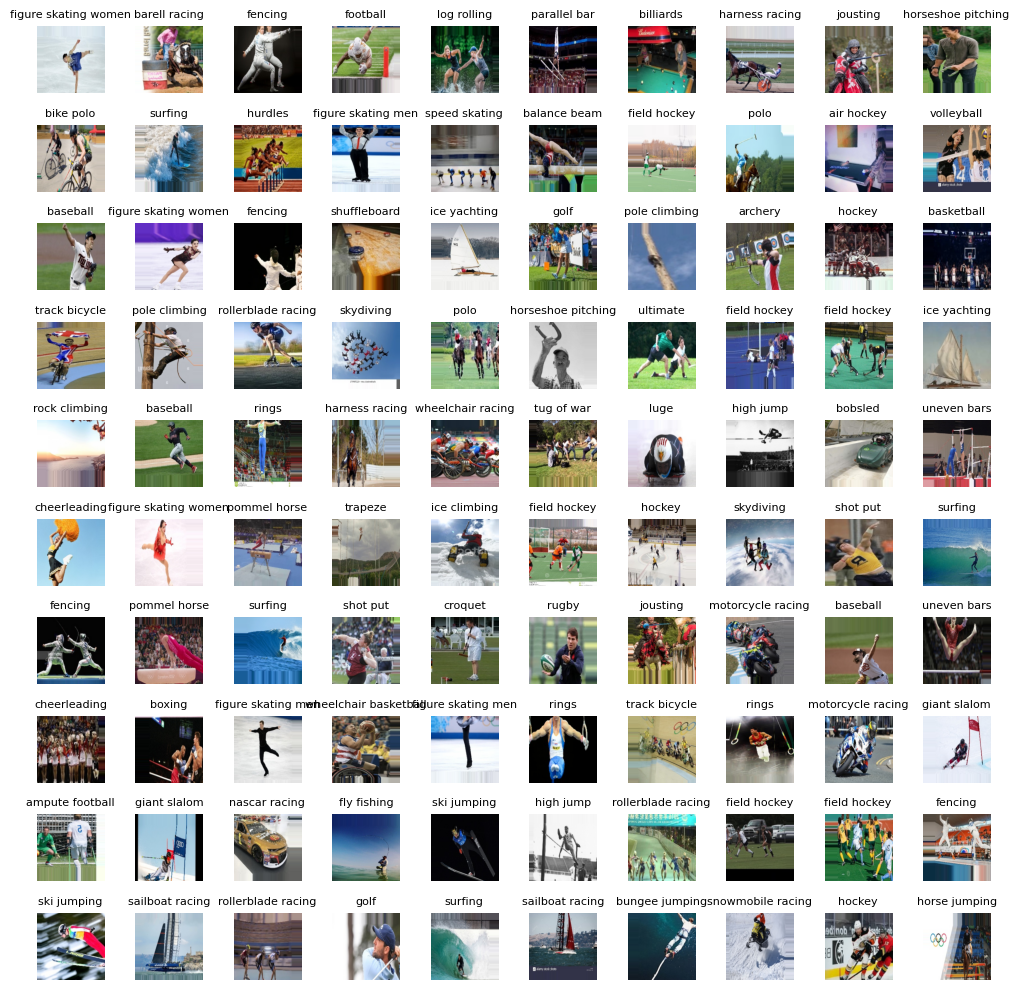

In [7]:
class_labels = {v: k for k, v in train_generator.class_indices.items()}

fig, axes = plt.subplots(10, 10, figsize=(10, 10), subplot_kw={'xticks': [], 'yticks': []})

for i, ax in enumerate(axes.flat):
    img = train_generator[0][0][i]
    label_index = np.argmax(train_generator[0][1][i])  # Uzyskanie indeksu klasy
    label_name = class_labels[label_index]  # Pobranie nazwy klasy
    ax.imshow(np.uint8(img))
    ax.set_title(label_name, fontsize=8)
    ax.axis('off')

plt.tight_layout()
plt.show()

# CNN

**Convolutional Neural Networks (CNN)** to specjalny rodzaj sieci neuronowych zaprojektowanych do efektywnego przetwarzania i klasyfikacji danych o strukturze siatkowej, takich jak obrazy. CNNs wykorzystują warstwy splotowe do automatycznego wykrywania istotnych cech w danych wejściowych, co czyni je niezwykle skutecznymi w zadaniach rozpoznawania obrazów.

In [11]:
warnings.filterwarnings('ignore')

model_cnn = Sequential()
model_cnn.add(Conv2D(32, (3, 3), activation='relu', input_shape=(224, 224, 3)))
model_cnn.add(MaxPooling2D((2, 2)))
model_cnn.add(Conv2D(64, (3, 3), activation='relu'))
model_cnn.add(MaxPooling2D((2, 2)))
model_cnn.add(Conv2D(128, (3, 3), activation='relu'))
model_cnn.add(MaxPooling2D((2, 2)))
model_cnn.add(Conv2D(256, (3, 3), activation='relu'))
model_cnn.add(MaxPooling2D((2, 2)))
model_cnn.add(Flatten())
model_cnn.add(Dense(512, activation='relu'))
model_cnn.add(Dropout(0.5))
model_cnn.add(Dense(len(train_generator.class_indices), activation='softmax'))
model_cnn.compile(optimizer='adam', loss ='categorical_crossentropy', metrics=['accuracy'])


zatrzymanie = EarlyStopping(monitor='val_accuracy', patience=10, restore_best_weights=True)




In [13]:
warnings.filterwarnings('ignore')
history_cnn = model_cnn.fit(
    train_generator,
    epochs=30,
    validation_data=validation_generator,
    callbacks=[zatrzymanie])

Epoch 1/30
 69/106 ━━━━━━━━━━━━━━━━━━━━ 1:24 2s/step - accuracy: 0.0130 - loss: 46.7614

2024-06-19 20:51:10.127855: E external/local_xla/xla/service/gpu/buffer_comparator.cc:1137] Difference at 98572: 8.00654, expected 7.09468
2024-06-19 20:51:10.127914: E external/local_xla/xla/service/gpu/buffer_comparator.cc:1137] Difference at 98573: 7.92824, expected 7.01637
2024-06-19 20:51:10.127924: E external/local_xla/xla/service/gpu/buffer_comparator.cc:1137] Difference at 98574: 7.63342, expected 6.72155
2024-06-19 20:51:10.127932: E external/local_xla/xla/service/gpu/buffer_comparator.cc:1137] Difference at 98575: 6.48562, expected 5.57375
2024-06-19 20:51:10.127941: E external/local_xla/xla/service/gpu/buffer_comparator.cc:1137] Difference at 98576: 6.65402, expected 5.74215
2024-06-19 20:51:10.127949: E external/local_xla/xla/service/gpu/buffer_comparator.cc:1137] Difference at 98577: 7.05533, expected 6.14346
2024-06-19 20:51:10.127957: E external/local_xla/xla/service/gpu/buffer_comparator.cc:1137] Difference at 98578: 7.10008, expected 6.18821
2024-06-19 20:51:10.127966:

106/106 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.0141 - loss: 101.3580

W0000 00:00:1718830345.166549     169 graph_launch.cc:671] Fallback to op-by-op mode because memset node breaks graph update
2024-06-19 20:52:28.725019: E external/local_xla/xla/service/slow_operation_alarm.cc:65] Trying algorithm eng15{k5=1,k6=0,k7=1,k10=1} for conv (f32[116,32,222,222]{3,2,1,0}, u8[0]{0}) custom-call(f32[116,3,224,224]{3,2,1,0}, f32[32,3,3,3]{3,2,1,0}, f32[32]{0}), window={size=3x3}, dim_labels=bf01_oi01->bf01, custom_call_target="__cudnn$convBiasActivationForward", backend_config={"conv_result_scale":1,"activation_mode":"kRelu","side_input_scale":0,"leakyrelu_alpha":0} is taking a while...
2024-06-19 20:52:29.028962: E external/local_xla/xla/service/gpu/buffer_comparator.cc:1137] Difference at 49289: 6.17863, expected 5.457
2024-06-19 20:52:29.029021: E external/local_xla/xla/service/gpu/buffer_comparator.cc:1137] Difference at 49291: 5.2566, expected 4.53497
2024-06-19 20:52:29.029038: E external/local_xla/xla/service/gpu/buffer_comparator.cc:1137] Difference at 49

106/106 ━━━━━━━━━━━━━━━━━━━━ 264s 2s/step - accuracy: 0.0142 - loss: 101.9695 - val_accuracy: 0.0080 - val_loss: 4.6086
Epoch 2/30
106/106 ━━━━━━━━━━━━━━━━━━━━ 160s 1s/step - accuracy: 0.0152 - loss: 492.6473 - val_accuracy: 0.0080 - val_loss: 4.5876
Epoch 3/30
106/106 ━━━━━━━━━━━━━━━━━━━━ 160s 1s/step - accuracy: 0.0141 - loss: 48.5952 - val_accuracy: 0.0100 - val_loss: 4.6072
Epoch 4/30
106/106 ━━━━━━━━━━━━━━━━━━━━ 161s 1s/step - accuracy: 0.0135 - loss: 39.5287 - val_accuracy: 0.0100 - val_loss: 4.6075
Epoch 5/30
106/106 ━━━━━━━━━━━━━━━━━━━━ 162s 1s/step - accuracy: 0.0146 - loss: 4.5958 - val_accuracy: 0.0100 - val_loss: 4.6104
Epoch 6/30
106/106 ━━━━━━━━━━━━━━━━━━━━ 162s 1s/step - accuracy: 0.0162 - loss: 4.5927 - val_accuracy: 0.0100 - val_loss: 4.6117
Epoch 7/30
106/106 ━━━━━━━━━━━━━━━━━━━━ 162s 1s/step - accuracy: 0.0144 - loss: 4.5940 - val_accuracy: 0.0120 - val_loss: 4.6065
Epoch 8/30
106/106 ━━━━━━━━━━━━━━━━━━━━ 161s 1s/step - accuracy: 0.0154 - loss: 4.5948 - val_accuracy:

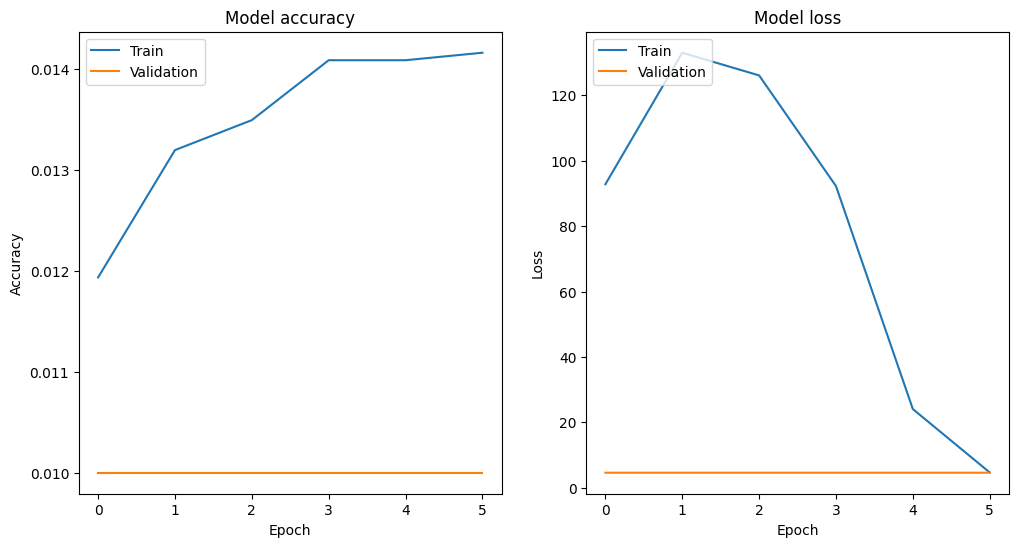

In [14]:
def plot_training_history(history):
    plt.figure(figsize=(12, 6))

   
    plt.subplot(1, 2, 1)
    plt.plot(history.history['accuracy'])
    plt.plot(history.history['val_accuracy'])
    plt.title('Model accuracy')
    plt.ylabel('Accuracy')
    plt.xlabel('Epoch')
    plt.legend(['Train', 'Validation'], loc='upper left')

    
    plt.subplot(1, 2, 2)
    plt.plot(history.history['loss'])
    plt.plot(history.history['val_loss'])
    plt.title('Model loss')
    plt.ylabel('Loss')
    plt.xlabel('Epoch')
    plt.legend(['Train', 'Validation'], loc='upper left')

    plt.show()


plot_training_history(history_cnn)

# Ewaluacja

In [16]:
train_loss, train_acc = model_cnn.evaluate(train_generator)
print(f"Dokładność na zbiorze treningowym: {train_acc}")
print(f"Strata na zbiorze treningowym: {train_loss}")
valid_loss, valid_acc = model_cnn.evaluate(validation_generator)
print(f"Dokładność na zbiorze walidacyjnym: {valid_acc}")
print(f"Strata na zbiorze walidacyjnym: {valid_loss}")
test_loss, test_acc = model_cnn.evaluate(test_generator)
print(f"Dokładność na zbiorze testowym: {test_acc}")
print(f"Strata na zbiorze testowym: {test_loss}")

106/106 ━━━━━━━━━━━━━━━━━━━━ 172s 2s/step - accuracy: 0.0134 - loss: 6.8130
Dokładność na zbiorze treningowym: 0.014008301310241222
Strata na zbiorze treningowym: 122.81400299072266
4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 407ms/step - accuracy: 0.0105 - loss: 4.6053
Dokładność na zbiorze walidacyjnym: 0.009999999776482582
Strata na zbiorze walidacyjnym: 4.60526180267334
4/4 ━━━━━━━━━━━━━━━━━━━━ 10s 3s/step - accuracy: 0.0105 - loss: 4.6053  
Dokładność na zbiorze testowym: 0.009999999776482582
Strata na zbiorze testowym: 4.60526180267334


## Wnioski 

Dokładność treningowa wynosi 0.014%, co oznacza, że model poprawnie klasyfikuje jedynie 1.4% obserwacji na zestawie treningowym. Strata na zestawie treningowym wynosi 122.81, co sugeruje, że model nie radzi sobie dobrze z przewidywaniem etykiet na danych treningowych.

Dokładność walidacyjna wynosi 0.01%, co wskazuje, że model poprawnie klasyfikuje jedynie 1% obserwacji na zestawie walidacyjnym. Strata walidacyjna wynosi 4.6053, co również wskazuje na słabą wydajność modelu na danych walidacyjnych.

Dokładność testowa wynosi 0.01%, co oznacza, że model poprawnie klasyfikuje jedynie 1% obserwacji na zestawie testowym. Strata na zestawie testowym wynosi 4.6053, co potwierdza niską skuteczność modelu na nowych danych.

Podsumowując, model CNN nie osiąga satysfakcjonującej dokładności ani na zestawie treningowym, ani na walidacyjnym, ani na testowym. Mimo że próbowałem zmieniać ilość epok przetrenowałem jeszcze dla 20 i 25 epok wszedzie wychodziło bardzo małe accuracy. 

Próbowałem też zmienić długość trenowania poprzedni kod wyglądał następująco
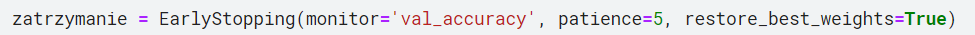

Dodałem również warstawe konwulucyjną poprzedni kod wyglądał następująco 
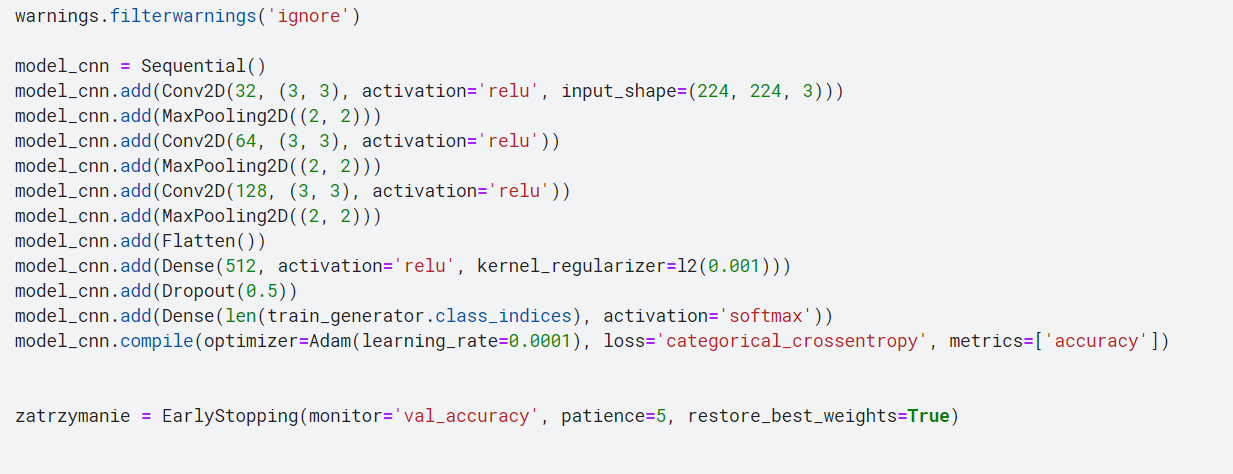



# ResNet50

ResNet50 to model konwolucyjnej sieci neuronowej (Convolutional Neural Network, CNN) opracowany przez badaczy z Microsoftu. Jest częścią rodziny modeli Residual Networks (ResNet), które wprowadziły innowacyjną koncepcję resztkowych połączeń (residual connections), pomagając w trenowaniu bardzo głębokich sieci neuronowych.

Resztkowe połączenia (shortcut connections) umożliwiają przepływ gradientów bezpośrednio przez kilka warstw, co pomaga rozwiązać problem zaniku gradientu (vanishing gradient) podczas trenowania bardzo głębokich sieci. Dzięki temu sieć może być znacznie głębsza niż tradycyjne modele, bez ryzyka pogorszenia jej wydajności.

ResNet50 składa się z 50 warstw, w tym wielu bloków resztkowych, które składają się z kilku warstw splotowych (convolutional layers) oraz połączeń skrótowych. Te połączenia pozwalają modelowi na lepsze wykrywanie i generalizowanie wzorców w danych, co czyni go niezwykle skutecznym w zadaniach związanych z rozpoznawaniem obrazów.

In [52]:
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.layers import Dense, Input, Dropout
from tensorflow.keras.models import Model

base_model = EfficientNetB0(weights="imagenet", include_top=False, input_shape=(224, 224, 3))
for layer in base_model.layers:
    layer.trainable = False

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dropout(0.5)(x)
predictions = Dense(len(train_generator.class_indices), activation='softmax')(x)

model_resnet = Model(inputs=base_model.input, outputs=predictions)

model_resnet.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

zatrzymanie = EarlyStopping(monitor='val_accuracy', patience=5, restore_best_weights=True)



In [55]:
history_resnet = model_resnet.fit(
    train_generator,
    epochs=30,
    validation_data=validation_generator,
    callbacks=[zatrzymanie]
)

Epoch 1/30
106/106 ━━━━━━━━━━━━━━━━━━━━ 258s 2s/step - accuracy: 0.3419 - loss: 3.1083 - val_accuracy: 0.8320 - val_loss: 1.1071
Epoch 2/30
106/106 ━━━━━━━━━━━━━━━━━━━━ 211s 2s/step - accuracy: 0.6962 - loss: 1.4416 - val_accuracy: 0.8860 - val_loss: 0.6355
Epoch 3/30
106/106 ━━━━━━━━━━━━━━━━━━━━ 201s 2s/step - accuracy: 0.7735 - loss: 1.0187 - val_accuracy: 0.9200 - val_loss: 0.4570
Epoch 4/30
106/106 ━━━━━━━━━━━━━━━━━━━━ 204s 2s/step - accuracy: 0.8103 - loss: 0.8180 - val_accuracy: 0.9240 - val_loss: 0.3678
Epoch 5/30
106/106 ━━━━━━━━━━━━━━━━━━━━ 221s 2s/step - accuracy: 0.8275 - loss: 0.7302 - val_accuracy: 0.9280 - val_loss: 0.3124
Epoch 6/30
106/106 ━━━━━━━━━━━━━━━━━━━━ 206s 2s/step - accuracy: 0.8434 - loss: 0.6516 - val_accuracy: 0.9420 - val_loss: 0.2756
Epoch 7/30
106/106 ━━━━━━━━━━━━━━━━━━━━ 278s 2s/step - accuracy: 0.8529 - loss: 0.5985 - val_accuracy: 0.9480 - val_loss: 0.2468
Epoch 8/30
106/106 ━━━━━━━━━━━━━━━━━━━━ 224s 2s/step - accuracy: 0.8609 - loss: 0.5579 - val_accu

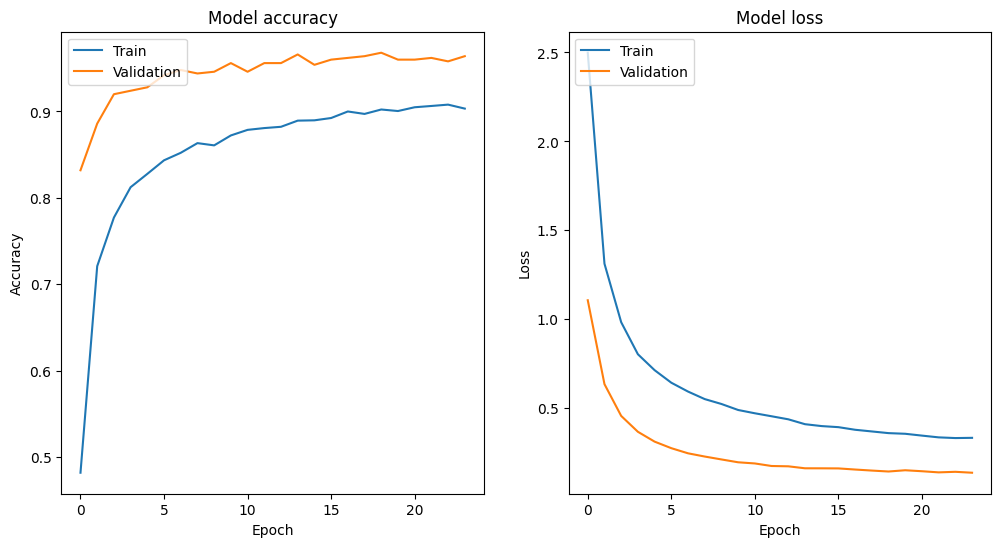

In [57]:

def plot_training_history(history):
    plt.figure(figsize=(12, 6))

   
    plt.subplot(1, 2, 1)
    plt.plot(history.history['accuracy'])
    plt.plot(history.history['val_accuracy'])
    plt.title('Model accuracy')
    plt.ylabel('Accuracy')
    plt.xlabel('Epoch')
    plt.legend(['Train', 'Validation'], loc='upper left')

    
    plt.subplot(1, 2, 2)
    plt.plot(history.history['loss'])
    plt.plot(history.history['val_loss'])
    plt.title('Model loss')
    plt.ylabel('Loss')
    plt.xlabel('Epoch')
    plt.legend(['Train', 'Validation'], loc='upper left')

    plt.show()


plot_training_history(history_resnet)

# Ewaluacja

In [61]:
train_loss, train_acc = model_resnet.evaluate(train_generator)
print(f"Dokładność na zbiorze treningowym: {train_acc}")
print(f"Strata na zbiorze treningowym: {train_loss}")
valid_loss, valid_acc = model_resnet.evaluate(validation_generator)
print(f"Dokładność na zbiorze walidacyjnym: {valid_acc}")
print(f"Strata na zbiorze walidacyjnym: {valid_loss}")
test_loss, test_acc = model_resnet.evaluate(test_generator)
print(f"Dokładność na zbiorze testowym: {test_acc}")
print(f"Strata na zbiorze testowym: {test_loss}")

106/106 ━━━━━━━━━━━━━━━━━━━━ 219s 2s/step - accuracy: 0.9582 - loss: 0.1934
Dokładność na zbiorze treningowym: 0.9549362659454346
Strata na zbiorze treningowym: 0.2034606784582138
4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 441ms/step - accuracy: 0.9695 - loss: 0.1459
Dokładność na zbiorze walidacyjnym: 0.9679999947547913
Strata na zbiorze walidacyjnym: 0.144500732421875
4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 446ms/step - accuracy: 0.9703 - loss: 0.1457
Dokładność na zbiorze testowym: 0.972000002861023
Strata na zbiorze testowym: 0.1395220309495926


## Wnioski 

Dokładność treningowa wynosi 95,49%, co oznacza, że model poprawnie klasyfikuje około 95,5% obserwacji na zestawie treningowym. Strata na zestawie treningowym wynosi 0.2035, co wskazuje, że model bardzo dobrze radzi sobie z przewidywaniem etykiet na danych treningowych.

Dokładność walidacyjna wynosi 96,80%, co oznacza, że model poprawnie klasyfikuje około 96,8% obserwacji na zestawie walidacyjnym. Strata walidacyjna wynosi 0.1445, co sugeruje, że model skutecznie generalizuje na danych walidacyjnych.

Dokładność testowa wynosi 97,20%, co oznacza, że model poprawnie klasyfikuje około 97,2% obserwacji na zestawie testowym. Strata na zestawie testowym wynosi 0.1395, co potwierdza bardzo dobrą wydajność modelu na nowych, niewidzianych wcześniej danych.

Podsumowując, model ResNet50 osiąga bardzo wysoką dokładność na zestawach treningowym, walidacyjnym i testowym, co wskazuje na jego doskonałą zdolność do nauki i generalizacji wzorców z danych.